# Hubble RGB Image Processing

Today I really wanted to just load a galaxy image. I don't know anything about Astronomical data analysis so all of this is very new. 

The target: 

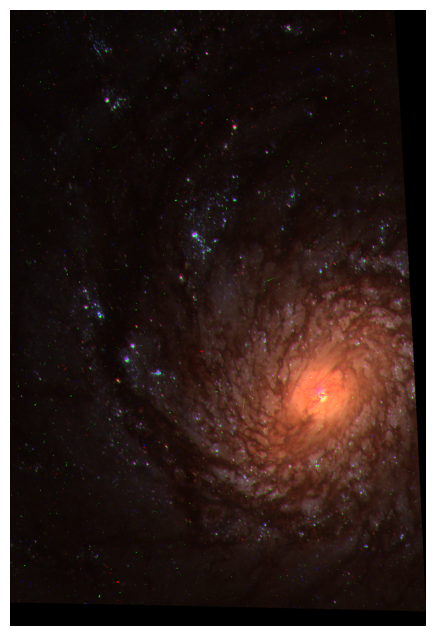

Note: notebook is running using the 'astro' kernel.

# Resources
-I watched "Astropy python for Astronomy Handling FITS files | RGB IMAGE FROM FITS FILE PYTHON ASTROPY by DESI ASTRO" on YouTube.
-debugging from ChatGPT.

# Finding FITS (Flexible Image Transport System) files
MAST is the Mikulski Archive for Space Telescopes, which stores astronomical datasets from missions like Hubble. Downloaded 3 Hubble M51 datasets, each corresponding to a different filter. (did you know they have beginner notebook tutorials for those interesetd in astronomical data analysis! How freaking cool!), with tags HST mission, science obsevation.

How to figure out fits files which ones have which colors?
F435W - blue visible light
F555W - green/visible light
F814W - red/near-infrared light

These filters are mapped to RGB colors for visualization. Hubble does not naturally take RGB photographs like a normal camera.

# Coding Process
1.) #import libraries

2.)  #read the FITS files. I read the files with eg r =fits.open('location and file name'). With r =fits.open('') (have to uncomment to run) gives a summary of whats in the FITS file, will tell us what to put in eg r_data[]
r.info() shows the structure of the FITS file and the available HDUs (Header/Data Units). It tells me which HDU contains the image data. For these Hubble files, the science image was stored in the SCI extension, so I used:
r['SCI'].data

3.) # Read image data
The FITS file contains lots of information, including metadata and different data extensions. I needed to identify where the actual science image data was stored. For these Hubble files, the image data was located in the SCI (science) extension:

r_data = r['SCI'].data

The data is stored as a large grid of numerical pixel values representing the intensity of light detected by the telescope. This is why NumPy is useful, astronomical images are essentially large arrays of numbers.

4.) # Match image dimensions between filters

To create an RGB image, the red, green, and blue image arrays need to have the same dimensions. Since the FITS files from different filters had slightly different image sizes, I trimemed each array to the smallest common shape.

make_lupton_rgb requires all three channels to have matching dimensions before combining them.

5.) # locate the galaxy and create a crop

I first tried to automatically locate the galaxy using the brightest pixel:

#brightness = np.mean(rgb, axis=2)
#y, x = np.unravel_index(np.argmax(brightness), brightness.shape)

However, this method failed because the brightest pixel belonged to a foreground star rather than the galaxy. Brightness alone is not enough to identify extended astronomical objects. The grid method is better.

Instead, I displayed the RGB image with a coordinate grid:

plt.figure(figsize=(10,10))
plt.imshow(rgb, origin="lower")
plt.xlim(0, rgb.shape[1])
plt.ylim(0, rgb.shape[0])
plt.grid()
plt.show()

The grid allowed me to manually identify M51's pixel coordinates and create a crop around the galaxy. Since astronomical images contain the telescope's entire field of view, the object is not automatically centered like a normal photograph.

6.) # make RGB image

After locating the galaxy, I created the final RGB composite using make_lupton_rgb and zoomed in on the galaxy's coordinates.

The red channel was initially too strong, so I adjusted the scaling of each channel. This happened because F814W observes longer wavelengths (near-infrared), which contains a large amount of light from older stars in the galaxy.

I also experimented with the stretch and Q parameters in make_lupton_rgb:
- stretch controls the overall brightness/contrast of the image
- Q controls how much the image emphasizes bright versus faint structures

This raised an interesting question: what is the "standard" way to color astronomical images? 

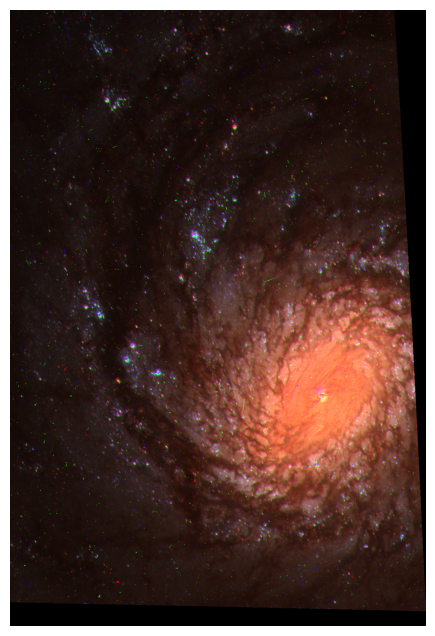

In [60]:
#import libraries
from astropy.io import fits #read fits file
import matplotlib.pyplot as plt #for plotting
import numpy as np #since telescope image is giant grid of numbers this helps!
from astropy.visualization import make_lupton_rgb #rgb image library

#read the fits files
r =fits.open('/home/lilly/Downloads/hst_10452_31_acs_wfc_f814w_j97c31_drc.fits')
g =fits.open('/home/lilly/Downloads/hst_10452_32_acs_wfc_f555w_j97c32_drc.fits')
b =fits.open('/home/lilly/Downloads/hst_10452_31_acs_wfc_f435w_j97c31_drc.fits')
#r.info() 

#read image data
r_data =r['SCI'].data
g_data =g['SCI'].data
b_data=b['SCI'].data 

#match image dimensions between filters
min_y = min(r_data.shape[0], g_data.shape[0], b_data.shape[0])
min_x = min(r_data.shape[1], g_data.shape[1], b_data.shape[1])

r_data = r_data[:min_y, :min_x]
g_data = g_data[:min_y, :min_x]
b_data = b_data[:min_y, :min_x]

#make rgb

rgb = make_lupton_rgb(
    r_data *0.5,
    g_data *0.7,
    b_data ,
    stretch=3, #controls overall brightness
    Q=1 #controls how much the image favors bright vs faint structures
)

#finding the galaxy
#brightness = np.mean(rgb, axis=2)
#y, x = np.unravel_index(np.argmax(brightness), brightness.shape)
#print("brightest pixel:", x, y)

#plot rgb image

crop = rgb[#crop reduces to this region
    0:1900,
    3000:4282
]

plt.figure(figsize=(8,8))
plt.imshow(crop, origin="lower")
plt.axis("off")
plt.show()